In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']

Testing VGG16
              precision    recall  f1-score   support

    Basophil       0.13      0.26      0.17        89
  Eosinophil       0.04      0.01      0.01       322
  Lymphocyte       0.93      0.87      0.90      1034
    Monocyte       0.29      0.81      0.43       234
  Neutrophil       0.93      0.87      0.90      2660

    accuracy                           0.79      4339
   macro avg       0.46      0.56      0.48      4339
weighted avg       0.81      0.79      0.79      4339



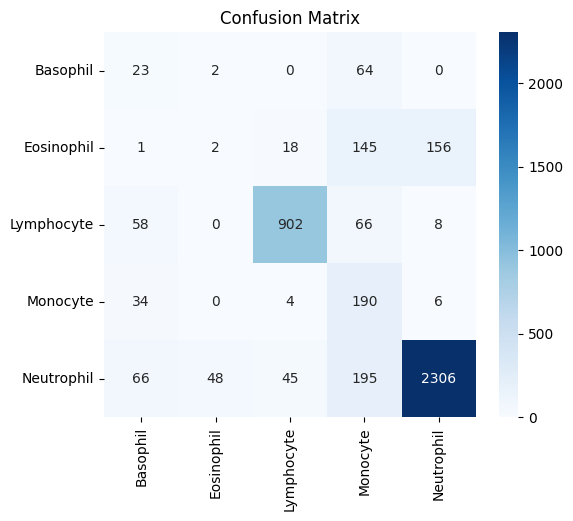


Testing ResNet50
              precision    recall  f1-score   support

    Basophil       0.06      0.10      0.08        89
  Eosinophil       0.13      0.98      0.23       322
  Lymphocyte       0.26      0.41      0.32      1034
    Monocyte       0.33      0.03      0.05       234
  Neutrophil       0.95      0.05      0.10      2660

    accuracy                           0.21      4339
   macro avg       0.35      0.31      0.15      4339
weighted avg       0.67      0.21      0.16      4339



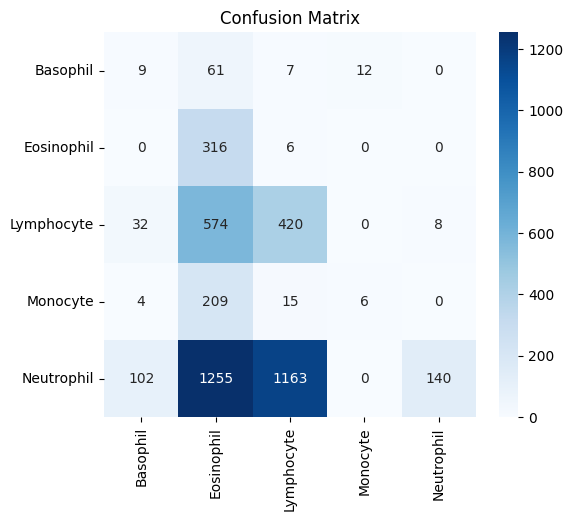


Testing ConvNeXt-Tiny
              precision    recall  f1-score   support

    Basophil       0.38      0.07      0.11        89
  Eosinophil       0.30      0.32      0.31       322
  Lymphocyte       1.00      0.74      0.85      1034
    Monocyte       0.85      0.29      0.43       234
  Neutrophil       0.84      0.99      0.91      2660

    accuracy                           0.82      4339
   macro avg       0.67      0.48      0.52      4339
weighted avg       0.83      0.82      0.81      4339



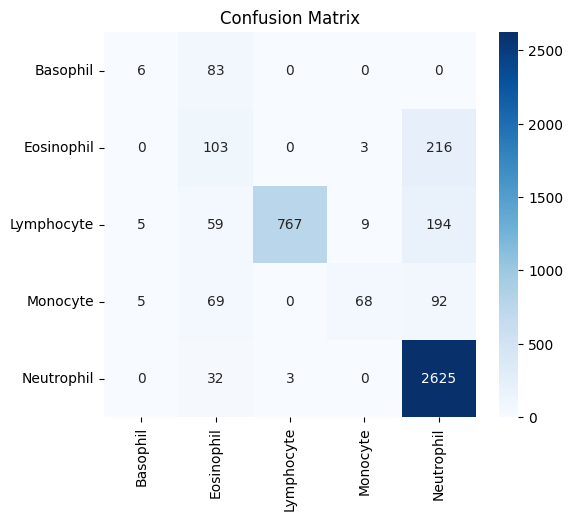


Testing ViT-B16
              precision    recall  f1-score   support

    Basophil       0.56      0.21      0.31        89
  Eosinophil       0.17      0.80      0.29       322
  Lymphocyte       0.97      0.80      0.88      1034
    Monocyte       0.71      0.60      0.65       234
  Neutrophil       0.96      0.64      0.77      2660

    accuracy                           0.68      4339
   macro avg       0.68      0.61      0.58      4339
weighted avg       0.88      0.68      0.74      4339



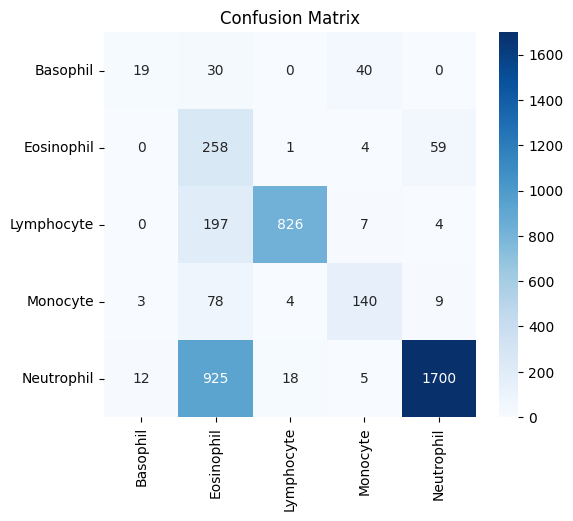

In [ ]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -------------------- CONFIG --------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TEST_DIR = "/content/drive/MyDrive/Raabin-WBC/Test-A"
BATCH_SIZE = 32
NUM_CELL_TYPES = 5  # ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
MODEL_PATHS = {
    "VGG16": "/content/drive/MyDrive/vgg16_saved_models/best_model.pth",
    "ResNet50": "/content/drive/MyDrive/resnet_saved_models/best_model.pth",
    "ConvNeXt-Tiny": "/content/drive/MyDrive/conv_next_saved_models/best_model.pth",
    "ViT-B16": "/content/drive/MyDrive/vit_b16_saved_models/best_model.pth"
}
FEATURE_DIMS = {"VGG16": 4096, "ResNet50": 2048, "ConvNeXt-Tiny": 768, "ViT-B16": 768}

# -------------------- DATASET --------------------
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
class_names = test_dataset.classes
print("Classes:", class_names)

# -------------------- MODEL DEFINITION --------------------
class AttributePredictor(nn.Module):
    def __init__(self, encoder, feat_dim, num_cell_types):
        super().__init__()
        self.encoder = encoder
        self.cell_head = nn.Linear(feat_dim, num_cell_types)

    def forward(self, x):
        features = self.encoder(x)
        return self.cell_head(features)

# -------------------- MODEL LOADER --------------------
def load_model(backbone_name, feature_dim, num_cell_types, checkpoint_path):
    # 1. Load backbone
    if backbone_name == "VGG16":
        encoder = models.vgg16(weights=None)
        encoder.classifier[6] = nn.Identity()
    elif backbone_name == "ResNet50":
        encoder = models.resnet50(weights=None)
        encoder.fc = nn.Identity()
    elif backbone_name == "ConvNeXt-Tiny":
        encoder = models.convnext_tiny(weights=None)
        encoder.classifier[-1] = nn.Identity()
    elif backbone_name == "ViT-B16":
        encoder = models.vit_b_16(weights=None)
        encoder.heads = nn.Identity()
    else:
        raise ValueError("Unknown backbone")

    model = AttributePredictor(encoder, feature_dim, num_cell_types).to(DEVICE)

    # 2. Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    state_dict = checkpoint.get("model_state", checkpoint)  # handle plain state_dict

    # Check if classifier exists in checkpoint
    classifier_keys = [k for k in state_dict.keys() if "cell_head" in k]
    if len(classifier_keys) == 0:
        print(f"⚠️ Warning: Classifier weights not found in checkpoint for {backbone_name}. Accuracy may be random.")

    # Load full state_dict
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    return model

# -------------------- EVALUATION --------------------
def evaluate_model(model, loader, class_names):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

# -------------------- RUN TEST --------------------
for name, path in MODEL_PATHS.items():
    print("\n" + "="*30)
    print(f"Testing {name}")
    try:
        model = load_model(name, FEATURE_DIMS[name], NUM_CELL_TYPES, path)
        evaluate_model(model, test_loader, class_names)
    except Exception as e:
        print(f"❌ Error testing {name}: {e}")
